# 4. 多层感知机

## 4.1 多层感知机

在 3.4 节中，我们介绍了 softmax 回归，从零开始实现了 softmax 回归，接着使用高级 API 实现了算法，并训练分类器从低分辨率图像中识别 10 类服装。在这个过程中，我们学习了如何处理数据，如何将输出转换为有效的概率分布，并应用适当的损失函数，根据模型参数最小化损失。

我们已经在简单的线性模型背景下掌握了这些知识，现在可以开始对深度神经网络的探索，这也是本书主要涉及的一类模型。

### 1. 隐藏层

仿射变换是一种带有偏置项的线性变换。softmax 回归通过单个仿射变换将输入直接映射到输出，再进行 softmax 操作。如果标签确实与输入数据线性相关，这种方法足够了。但是，仿射变换中的**线性**是一个很强的假设。

#### 1.1 线性模型可能会出错

线性意味着**单调性假设**：任何特征的增大都会导致模型输出的增大（如果对应的权重为正），或者导致模型输出的减小（如果对应的权重为负）。有些场景可以靠特征预处理挽救，但更多场景无能为力：

- **单调但非线性**：预测贷款人是否会还款，收入越高还款可能性越大。但收入从 0 增加到 5 万，可能比从 100 万增加到 105 万带来更大的还款可能性。可以用对数变换等预处理让线性变得更合理。
- **违反单调性**：根据体温预测死亡率。对体温高于 37℃ 的人，温度越高风险越大；对低于 37℃ 的人，温度越高风险越低。可以用"与 37℃ 的距离"作为特征来补救。
- **特征交互**：对猫狗图像分类，增加位置 $(13, 17)$ 处像素的强度并不总是增加（或降低）图像是狗的似然——任何像素的重要性都以复杂的方式取决于该像素的上下文（周围像素的值）。这难以通过简单的预处理解决。

对于深度神经网络，我们使用观测数据来**联合学习隐藏层表示和应用于该表示的线性预测器**。

#### 1.2 在网络中加入隐藏层

在网络中加入一个或多个隐藏层，可以克服线性模型的限制。最简单的方法是将许多全连接层堆叠在一起：每一层都输出到上面的层，直到生成最后的输出。我们可以把前 $L-1$ 层看作表示，把最后一层看作线性预测器。这种架构通常称为**多层感知机**（multilayer perceptron，MLP）。

![一个单隐藏层的多层感知机，具有5个隐藏单元](src/mlp.svg)

图中这个多层感知机有 4 个输入，3 个输出，隐藏层包含 5 个隐藏单元。输入层不涉及任何计算，因此使用此网络产生输出只需要实现隐藏层和输出层的计算，所以这个多层感知机中的**层数为 2**。这两个层都是全连接的：每个输入都会影响隐藏层中的每个神经元，而隐藏层中的每个神经元又会影响输出层中的每个神经元。

然而，具有全连接层的多层感知机的参数开销可能高得令人望而却步。即使在不改变输入或输出大小的情况下，也可能需要在参数节约和模型有效性之间进行权衡。

### 2. 从线性到非线性

设小批量样本用矩阵 $\mathbf{X} \in \mathbb{R}^{n \times d}$ 表示（$n$ 个样本、每个样本 $d$ 个输入特征）。对于具有 $h$ 个隐藏单元的单隐藏层多层感知机，用 $\mathbf{H} \in \mathbb{R}^{n \times h}$ 表示隐藏层的输出，称为**隐藏表示**（hidden representation），也称为隐藏层变量或隐藏变量。因为隐藏层和输出层都是全连接的，所以有隐藏层权重 $\mathbf{W}^{(1)} \in \mathbb{R}^{d \times h}$、隐藏层偏置 $\mathbf{b}^{(1)} \in \mathbb{R}^{1 \times h}$，以及输出层权重 $\mathbf{W}^{(2)} \in \mathbb{R}^{h \times q}$、输出层偏置 $\mathbf{b}^{(2)} \in \mathbb{R}^{1 \times q}$。单隐藏层多层感知机的输出 $\mathbf{O} \in \mathbb{R}^{n \times q}$ 按如下方式计算：

$$
\begin{aligned}
    \mathbf{H} & = \mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}, \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.
\end{aligned}
$$

#### 2.1 仿射函数的仿射函数仍是仿射函数

在上面定义的模型里，加入隐藏层并没有带来任何好处：隐藏单元由输入的仿射函数给出，而输出（softmax 操作前）只是隐藏单元的仿射函数。事实上，对于任意权重值，只需合并隐藏层，便可产生等价的单层模型：

$$
\mathbf{O} = (\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})\mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W}^{(1)}\mathbf{W}^{(2)} + \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W} + \mathbf{b}.
$$

其中等效参数为 $\mathbf{W} = \mathbf{W}^{(1)}\mathbf{W}^{(2)}$ 和 $\mathbf{b} = \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)}$。

#### 2.2 加入激活函数

为了发挥多层架构的潜力，还需要一个额外的关键要素：在仿射变换之后对每个隐藏单元应用非线性的**激活函数**（activation function）$\sigma$。激活函数的输出（例如 $\sigma(\cdot)$）被称为**活性值**（activations）。有了激活函数，多层感知机就不可能再退化成线性模型：

$$
\begin{aligned}
    \mathbf{H} & = \sigma(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}), \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.\\
\end{aligned}
$$

由于 $\mathbf{X}$ 中的每一行对应小批量中的一个样本，非线性函数 $\sigma$ 也按行的方式作用于其输入，即一次计算一个样本；而且激活函数通常不仅按行操作，也**按元素操作**——计算每个活性值时不需要查看其他隐藏单元所取的值。

为了构建更通用的多层感知机，可以继续堆叠这样的隐藏层，例如 $\mathbf{H}^{(1)} = \sigma_1(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})$ 和 $\mathbf{H}^{(2)} = \sigma_2(\mathbf{H}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)})$，一层叠一层，从而产生更有表达能力的模型。

#### 2.3 通用近似定理

多层感知机可以通过隐藏神经元捕捉到输入之间复杂的相互作用，这些神经元依赖于每个输入的值。即使网络只有一个隐藏层，给定足够的神经元和正确的权重，我们也可以对任意函数建模（多层感知机是**通用近似器**），尽管实际中学习该函数是很困难的。神经网络有点像 C 语言：它能表达任何可计算的程序，但实际上想出一个符合规范的程序才是最困难的部分。

而且，虽然单隐藏层网络能学习任何函数，但并不意味着我们应该用单隐藏层网络来解决所有问题。事实上，通过使用**更深（而不是更广）**的网络，我们可以更容易地逼近许多函数。

In [1]:

import torch

# 仿射函数的仿射函数仍是仿射函数：两层"线性网络"可合并为一层
# O = (X W1 + b1) W2 + b2 = X (W1 W2) + (b1 W2 + b2) = X W + b
torch.manual_seed(0)
n, d, h, q = 4, 5, 6, 3
X = torch.randn(n, d)
W1, b1 = torch.randn(d, h), torch.randn(1, h)
W2, b2 = torch.randn(h, q), torch.randn(1, q)

O_two_layer = (X @ W1 + b1) @ W2 + b2
O_one_layer = X @ (W1 @ W2) + (b1 @ W2 + b2)

print('两种计算方式的输出一致：', torch.allclose(O_two_layer, O_one_layer))
print('合并后的等效参数 W 形状:', (W1 @ W2).shape, '，b 形状:', (b1 @ W2 + b2).shape)


两种计算方式的输出一致： True
合并后的等效参数 W 形状: torch.Size([5, 3]) ，b 形状: torch.Size([1, 3])


### 3. 激活函数

**激活函数**（activation function）通过计算加权和并加上偏置来确定神经元是否应该被激活，它们是将输入信号转换为输出的可微运算。大多数激活函数都是非线性的。由于激活函数是深度学习的基础，下面简要介绍一些常见的激活函数。

#### 3.1 ReLU 函数

最受欢迎的激活函数是**修正线性单元**（Rectified linear unit，ReLU），因为它实现简单，同时在各种预测任务中表现良好。ReLU 提供了一种非常简单的非线性变换：给定元素 $x$，ReLU 函数被定义为该元素与 $0$ 的最大值：

$$\operatorname{ReLU}(x) = \max(x, 0).$$

通俗地说，ReLU 函数通过将相应的活性值设为 0，仅保留正元素并丢弃所有负元素。它是**分段线性**的。

当输入为负时，ReLU 的导数为 0；当输入为正时，导数为 1。输入恰好为 0 时 ReLU 不可导，此时默认使用左侧的导数，即输入为 0 时导数为 0。我们可以忽略这种情况，因为输入可能永远都不会是 0——正如一句古老的谚语所说，"如果微妙的边界条件很重要，我们很可能是在研究数学而非工程"。

使用 ReLU 的原因是，它求导表现得特别好：要么让参数消失，要么让参数通过。这使得优化表现得更好，并且 ReLU 减轻了困扰以往神经网络的**梯度消失**问题。

ReLU 函数有许多变体，包括**参数化 ReLU**（Parameterized ReLU，pReLU）。该变体为 ReLU 添加了一个线性项，因此即使参数是负的，某些信息仍然可以通过：

$$\operatorname{pReLU}(x) = \max(0, x) + \alpha \min(0, x).$$

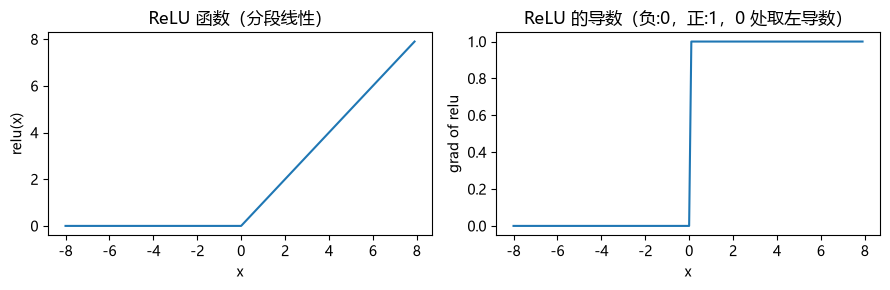

In [2]:

import torch
import matplotlib.pyplot as plt

# 中文字体设置：matplotlib 默认字体不含中文，需指定 Windows 中文字体，否则显示为方框
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
y.backward(torch.ones_like(x))  # 对各元素求和再求导，等价于对每个元素分别求导

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(x.detach(), y.detach())
axes[0].set_xlabel('x'); axes[0].set_ylabel('relu(x)')
axes[0].set_title('ReLU 函数（分段线性）')
axes[1].plot(x.detach(), x.grad)
axes[1].set_xlabel('x'); axes[1].set_ylabel('grad of relu')
axes[1].set_title('ReLU 的导数（负:0，正:1，0 处取左导数）')
fig.tight_layout()
plt.show()


#### 3.2 sigmoid 函数

对于定义域在 $\mathbb{R}$ 中的输入，**sigmoid 函数**将输入变换为区间 $(0, 1)$ 上的输出。因此 sigmoid 通常称为**挤压函数**（squashing function）：它将范围 $(-\infty, \infty)$ 中的任意输入压缩到区间 $(0, 1)$ 中的某个值：

$$\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.$$

在最早的神经网络中，科学家们感兴趣的是对"激发"或"不激发"的生物神经元进行建模，这一领域的先驱（人工神经元的发明者麦卡洛克和皮茨）专注于阈值单元：输入低于某个阈值时取值 0，超过阈值时取值 1。当人们逐渐关注基于梯度的学习时，sigmoid 函数是一个自然的选择，因为它是一个平滑的、可微的阈值单元近似。

当输入接近 0 时，sigmoid 函数接近线性变换。

sigmoid 函数的导数为：

$$\frac{d}{dx} \operatorname{sigmoid}(x) = \frac{\exp(-x)}{(1 + \exp(-x))^2} = \operatorname{sigmoid}(x)\left(1-\operatorname{sigmoid}(x)\right).$$

当输入为 0 时，sigmoid 函数的导数达到最大值 0.25；输入在任一方向上越远离 0 点，导数越接近 0。

sigmoid 在隐藏层中已经较少使用（大部分时候被更简单、更容易训练的 ReLU 所取代），但当我们想要将输出视作二元分类问题的概率时，sigmoid 仍被广泛用作输出单元上的激活函数（sigmoid 可以视为 softmax 的特例）。在后面关于循环神经网络的章节中，还将利用 sigmoid 单元来控制时序信息流。

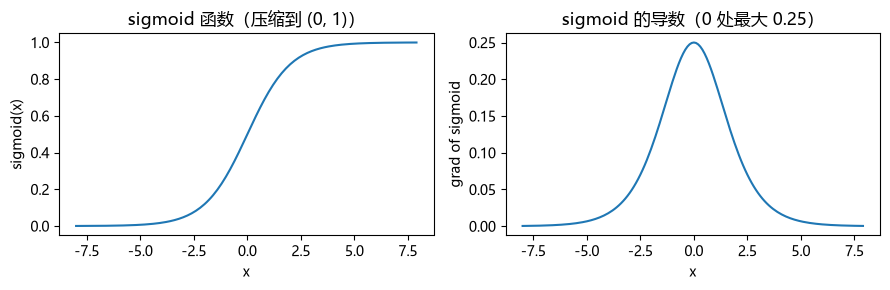

In [3]:

import torch
import matplotlib.pyplot as plt

# 中文字体设置：matplotlib 默认字体不含中文，需指定 Windows 中文字体，否则显示为方框
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))  # 对各元素求和再求导，等价于对每个元素分别求导

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(x.detach(), y.detach())
axes[0].set_xlabel('x'); axes[0].set_ylabel('sigmoid(x)')
axes[0].set_title('sigmoid 函数（压缩到 (0, 1)）')
axes[1].plot(x.detach(), x.grad)
axes[1].set_xlabel('x'); axes[1].set_ylabel('grad of sigmoid')
axes[1].set_title('sigmoid 的导数（0 处最大 0.25）')
fig.tight_layout()
plt.show()


#### 3.3 tanh 函数

与 sigmoid 函数类似，**tanh（双曲正切）函数**也能将其输入压缩转换到区间 $(-1, 1)$ 上：

$$\operatorname{tanh}(x) = \frac{1 - \exp(-2x)}{1 + \exp(-2x)}.$$

当输入在 0 附近时，tanh 函数接近线性变换。函数的形状类似于 sigmoid 函数，不同的是 tanh 函数关于坐标系**原点中心对称**。

tanh 函数的导数是：

$$\frac{d}{dx} \operatorname{tanh}(x) = 1 - \operatorname{tanh}^2(x).$$

当输入接近 0 时，tanh 函数的导数接近最大值 1。与 sigmoid 函数图像中看到的类似，输入在任一方向上越远离 0 点，导数越接近 0。

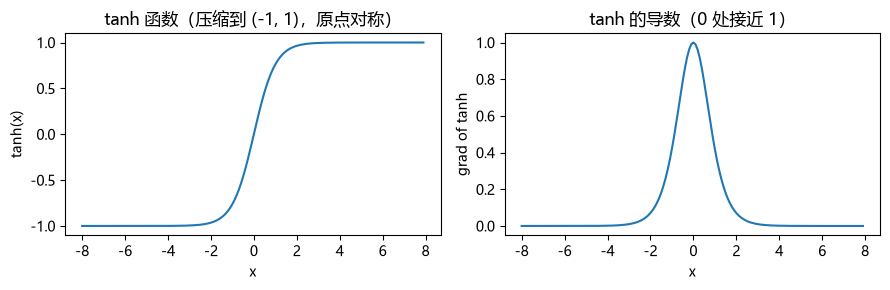

In [4]:

import torch
import matplotlib.pyplot as plt

# 中文字体设置：matplotlib 默认字体不含中文，需指定 Windows 中文字体，否则显示为方框
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.tanh(x)
y.backward(torch.ones_like(x))  # 对各元素求和再求导，等价于对每个元素分别求导

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(x.detach(), y.detach())
axes[0].set_xlabel('x'); axes[0].set_ylabel('tanh(x)')
axes[0].set_title('tanh 函数（压缩到 (-1, 1)，原点对称）')
axes[1].plot(x.detach(), x.grad)
axes[1].set_xlabel('x'); axes[1].set_ylabel('grad of tanh')
axes[1].set_title('tanh 的导数（0 处接近 1）')
fig.tight_layout()
plt.show()


## 4.2 多层感知机的从零实现

我们已经在 4.1 节中描述了多层感知机（MLP），现在让我们尝试自己实现一个多层感知机。

为了与之前 softmax 回归获得的结果进行比较，我们将继续使用 **Fashion-MNIST 图像分类数据集**。本节的要点：手动初始化模型参数、自己实现 ReLU 激活函数、搭建单隐藏层网络，并借助 `d2l` 库直接复用第 3 章的数据加载与训练流程。

### 4. 加载数据集

继续使用 **Fashion-MNIST 图像分类数据集**，批量大小保持为 256。

这里直接使用 `d2l.load_data_fashion_mnist`（内部通过 torchvision 下载并加载数据集，默认存放于 `../data` 目录）。Windows 上多进程 DataLoader 容易出现兼容性问题，因此先把工作进程数设为 0。

In [13]:

import torch
from torch import nn
from d2l import torch as d2l

# Windows 上将 DataLoader 工作进程数设为 0，避免多进程兼容性问题
d2l.get_dataloader_workers = lambda: 0

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)


### 5. 初始化模型参数

回想一下，Fashion-MNIST 中的每个图像由 $28 \times 28 = 784$ 个灰度像素值组成，所有图像共分为 10 个类别。忽略像素之间的空间结构，我们可以将每个图像视为具有 784 个输入特征和 10 个类的简单分类数据集。

首先，我们实现一个**具有单隐藏层的多层感知机，它包含 256 个隐藏单元**。注意，我们可以将这两个量都视为超参数。通常，我们选择 2 的若干次幂作为层的宽度——因为内存在硬件中的分配和寻址方式，这么做往往可以在计算上更高效。

我们用几个张量来表示我们的参数。注意，对于每一层我们都要记录一个权重矩阵和一个偏置向量。跟以前一样，我们要为损失关于这些参数的梯度分配内存（`requires_grad=True`，并用 `nn.Parameter` 注册参数，便于传给优化器）。

In [14]:

num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]


### 6. 激活函数

为了确保我们对模型的细节了如指掌，我们**自己实现 ReLU 激活函数**，而不是直接调用内置的 `relu` 函数：用 `torch.zeros_like(X)` 生成与 `X` 同形状的全 0 张量，再取逐元素最大值。

In [15]:

def relu(X):
    """自实现的 ReLU 激活函数"""
    a = torch.zeros_like(X)
    return torch.max(X, a)


### 7. 模型

因为我们忽略了空间结构，所以我们使用 `reshape` 将每个二维图像转换为一个长度为 `num_inputs` 的向量。只需几行代码就可以实现我们的模型：隐藏层仿射变换 → ReLU 激活 → 输出层仿射变换。

In [16]:

def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X @ W1 + b1)  # 这里“@”代表矩阵乘法
    return (H @ W2 + b2)


### 8. 损失函数

由于我们已经从零实现过 softmax 函数（3.4 节），因此在这里直接使用高级 API 中的内置函数来计算 softmax 和交叉熵损失。回想一下 3.7 节中关于数值稳定性（上溢、下溢与 LogSumExp 技巧）的讨论，`nn.CrossEntropyLoss(reduction='none')` 直接接收 logits 并逐样本计算损失。我们鼓励感兴趣的读者查看损失函数的源代码，以加深对实现细节的了解。

In [17]:

loss = nn.CrossEntropyLoss(reduction='none')


### 9. 训练

幸运的是，**多层感知机的训练过程与 softmax 回归的训练过程完全相同**。直接调用 `d2l.train_ch3`（内部使用 `Animator` 动画实时绘制训练损失、训练精度与测试精度曲线），将迭代周期数设置为 10，学习率设置为 0.1。

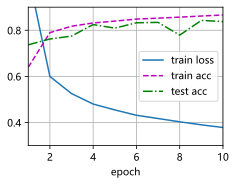

In [18]:

num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)

d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)


### 10. 在一些测试数据上应用模型

为了对学习到的模型进行评估，我们在一些测试数据上应用这个模型：调用 `d2l.predict_ch3` 可视化部分测试样本的**真实标签与预测标签**（每个图像上方第一行为真实标签，第二行为预测标签）。

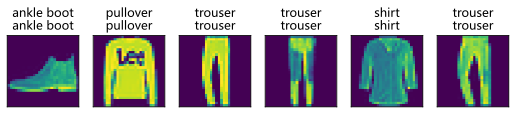

In [19]:

d2l.predict_ch3(net, test_iter)


# 多层感知机的简洁实现

In [20]:
import torch
from torch import nn
from d2l import torch as d2l

In [21]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))


def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)


net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

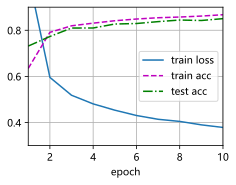

In [22]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction="none")
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

## 4.4 欠拟合、过拟合和模型选择

机器学习的根本问题不是"把训练数据拟合得多好"，而是**发现能泛化的模式**——即模型在从未见过的样本上依然有效的规律。如果模型只是"记住"了训练数据（比如基因数据可以唯一确定每个患者，模型完全可能背下"那是鲍勃，他有痴呆症"），那么部署后面对新样本就会失败。只有当模型真正发现了泛化模式，才能对以前从未遇到的个体作出有效预测。

- **过拟合**：模型在训练数据上拟合得比在潜在分布（真实总体）上更近的现象；
- **正则化**：用于对抗过拟合的一系列技术。

在 Fashion-MNIST 实验中你可能已经见过它：只要神经元、层数和训练迭代周期足够多，模型最终可以在训练集上达到完美精度，而测试精度却下降了。

三个经典思维实验帮助建立直觉：

1. **备考的学生**：靠死记硬背往年考题答案的学生，可能往年题满分、真考就崩；理解解题原因的学生才能应对新题。训练集=往年考题，测试集=真考卷；
2. **查表模型**：对 $28\times 28$ 灰度图，每像素 256 种取值，可能的图像有 $256^{784}$ 张——比宇宙中的原子还多，任何查找表都不可能覆盖。当输入空间远大于训练样本数时，"记忆"注定失败；
3. **掷硬币**：公平硬币的泛化误差恒为 $1/2$，但小样本（如 {0,1,1,1,0,1}）上"总预测多数类"的训练误差可以低至 $1/3$——**小样本上的训练误差会乐观地偏离泛化误差**，数据增多后两者逐渐匹配。

本节结构：先定义训练误差与泛化误差（### 11），再讲如何用验证集/K 折交叉验证做模型选择（### 12），然后给出欠拟合/过拟合的判别方法与"模型复杂度—误差"曲线（### 13），最后用一个多项式回归实验把三种情况真实跑一遍（### 14–18），并补充偏差—方差分解深入原理（### 19）。

### 11. 训练误差与泛化误差

**定义**

- **训练误差**（training error）：模型在**训练数据集**上计算得到的误差；
- **泛化误差**（generalization error）：模型应用在"从原始样本的分布中抽取的**无限多**新样本"上时误差的期望。

关键事实：**泛化误差永远无法精确计算**（"无限多样本"只是理论对象）。实践中只能把模型应用在一个独立的、未参与训练的**测试集**上来估计它。

**i.i.d. 假设**

统计学习理论通常假设训练数据与测试数据都是从同一分布中**独立同分布**（i.i.d.）抽取的：采样过程没有"记忆"，第 2 个样本与第 3 个样本的相关性，并不比第 2 个与第 200 万个的相关性更强。理论上，Glivenko–Cantelli 定理刻画了训练误差收敛到泛化误差的速率；Vapnik–Chervonenkis（VC 维）理论将其推广到更一般的函数类，奠定了统计学习理论的基础。

但现实中 i.i.d. 经常有漏洞，需要批判性地检查：

- **跨分布迁移**：用加州大学旧金山分校医疗中心患者数据训练的死亡风险模型，直接用于马萨诸塞州综合医院的患者——两地人群分布可能并不相同；
- **时间依赖**：对微博主题分类时，新闻周期使话题随时间漂移，违反独立性；
- 轻微违背 i.i.d. 时模型往往仍然工作良好（人脸识别、语音识别、机器翻译等成功应用几乎都存在违背）；但严重违背必然失败——比如只用大学生人脸训练的识别系统，去监测疗养院的老人。
- 值得一提：能解释深度神经网络泛化性能的完整理论，至今仍困扰着学习理论领域最优秀的学者。

**什么因素让模型"复杂"？**

模型是否能很好地泛化取决于很多因素，倾向影响泛化的三点：

1. **可调整参数的数量**（自由度）：参数越多，模型往往越容易过拟合；
2. **参数采用的值**：权重取值范围越大越容易过拟合（大权重让函数更"陡峭灵活"）；
3. **训练样本数量**：一两个样本的"数据集"随便什么模型都能过拟合；过拟合数百万样本的数据集则需要一个极其灵活的模型。

> 延伸（自己的知识）：只最小化训练误差的做法叫**经验风险最小化**（ERM）；而泛化好的模型实质上是在最小化"经验风险 + 复杂度惩罚"（**结构风险最小化**的思想）——这正是 4.5 节权重衰减、4.6 节 dropout 等正则化手段的理论动机。另外记住一个不对称性：**训练误差是泛化误差的乐观估计**——模型是"看着训练集"调出来的，它只会偏低、不会偏高。

### 12. 模型选择：验证集与 K 折交叉验证

**模型选择**（model selection）：在多个候选模型中选出最终模型。候选可以是本质不同的模型类（决策树 vs 线性模型），也可以是同类模型的不同超参数设置（隐藏层数、隐藏单元数、激活函数组合等）。

**为什么既不能只用测试集、也不能只用训练集来选模型？**

- **不能用测试集**：在模型选择过程中反复使用测试数据，就有"过拟合测试集"的风险——过拟合了训练数据，还可以靠测试集上的评估来发现；**但过拟合了测试数据，你又该怎么知道呢？** 测试集必须留到所有超参数确定之后评估一次；
- **不能只用训练集**：训练误差无法估计泛化误差（训练误差几乎总随模型变复杂而下降）。

因此常见做法是把数据分成三份：**训练集**（拟合参数）、**验证集**（validation set，选模型/调超参数）、**测试集**（最终评估）。

> 现实提醒：验证数据与测试数据之间的边界在实践中模糊得令人担忧——测试集很少"用一次就丢弃"，我们也很少有充足的数据为每轮实验准备全新测试集。本书实验中报告的准确度实际上都是**验证集准确度**（除非另有说明，并没有真正的测试集）。

**K 折交叉验证**（K-fold cross-validation）

训练数据稀缺、连一个合适的验证集都凑不出来时的标准方案：

1. 将原始训练数据分成 $K$ 个不重叠的子集（"折"，fold）；
2. 执行 $K$ 轮"训练+验证"：第 $i$ 轮在除去第 $i$ 折的 $K-1$ 折上训练，在第 $i$ 折上验证；
3. 对 $K$ 轮的误差取平均，作为训练/验证误差的估计。

> 延伸：常用 $K=5$ 或 $10$。$K$ 越大，每轮训练数据越多（估计偏差越小），但各验证折越小（方差越大），且训练成本乘以 $K$；极端 $K=n$ 称为**留一法**（leave-one-out），小数据集可用但计算昂贵。注意每轮都要**从头重新初始化并训练模型**，不能复用上一轮的权重。

### 13. 欠拟合还是过拟合？

比较训练误差与验证误差，有两大典型模式：

| 现象 | 判断 | 含义 |
| --- | --- | --- |
| 训练误差和验证误差都很高，且两者差距很小 | **欠拟合**（underfitting） | 模型过于简单（表达能力不足），连训练数据中的模式都抓不住；有理由相信用更复杂的模型可以降低训练误差 |
| 训练误差明显低于验证误差 | **过拟合**（overfitting） | 模型把训练数据中的噪声也学了进去。注意过拟合**并不总是一件坏事**——深度学习中最好的预测模型在训练数据上的表现往往比在保留数据上好得多；我们最终更关心**验证误差本身**，而不是差距 |

**用多项式理解模型复杂度**

给定单特征 $x$ 与实数标签 $y$，用 $d$ 阶多项式拟合：

$$\hat{y} = \sum_{i=0}^{d} x^i w_i$$

这本质上仍是**线性回归**（特征由 $x$ 的幂给出，权重是 $w_i$，偏置是 $w_0$，因为对所有 $x$ 都有 $x^0=1$），损失用平方误差。要点：

- 高阶多项式参数更多、可表示的函数空间更大，因此在固定训练集上，**训练误差随阶数 $d$ 单调不增**（最坏也相等）；
- 当阶数等于样本数（且 $x$ 各不相同时），多项式可以**完美插值**训练集——训练误差为 0，但泛化往往灾难性地差；
- 下图展示这一经典直觉：训练误差随复杂度单调下降，泛化误差先降后升呈 U 型；两者缝隙拉大的区域就是过拟合区。

**数据集大小**

训练样本越少，就越有可能（且越严重地）过拟合；随着数据量增加，泛化误差通常减小。模型复杂度应与数据量匹配：数据多时可以拟合更复杂的模型，数据不足时简单模型反而更有用。对许多任务，深度学习要有数千个训练样本才优于线性模型——深度学习的生机很大程度上归功于廉价存储与数字化经济带来的海量数据。

### 14. 多项式函数拟合实验：生成数据集

我们用一个能"知道标准答案"的实验来直观体会上述概念。给定 $x$，用下面的**三阶**多项式生成训练与测试数据的标签：

$$y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.1^2)$$

- 真实权重 $w = [5, 1.2, -3.4, 5.6]$，噪声项 $\epsilon$ 服从均值为 0、标准差为 0.1 的正态分布；
- 训练集与测试集各生成 100 个样本；
- **为什么要除以 $i!$？** 把特征从 $x^i$ 缩放为 $x^i/i!$（gamma 函数归一化，$\Gamma(n)=(n-1)!$），避免高阶特征数值爆炸——例如 $x=2$ 时 $x^{19}\approx 5\times 10^5$，会带来特别大的指数值/梯度/损失，使优化不稳定。这是一个通用技巧：**归一化输入特征有利于优化**（与 4.10 节数值稳定性呼应）；
- 代码一次性生成 20 阶的全部多项式特征 `poly_features`（$1, x, x^2/2!, \dots, x^{19}/19!$），训练时**只取前 $d$ 列**喂给模型——于是不用重新造数据，切个片就能控制模型复杂度 $d$。

### 15. 对模型进行训练和测试

先实现一个评估函数：计算模型在给定数据集上的平均损失（复用第 3 章的 `d2l.Accumulator` 累加器）。

训练函数的关键设计：

- 模型 `nn.Sequential(nn.Linear(input_shape, 1, bias=False))` 仍然是**线性回归**——多项式拟合的"复杂度"完全由喂进去的特征列数决定，模型结构本身不变；
- **不设置偏置**：因为 $x^0/0! = 1$ 这一列常量特征已经充当了偏置 $w_0$；
- 损失用均方误差 `nn.MSELoss(reduction='none')`，优化器 SGD（lr=0.01），小批量大小 `min(10, n)`；
- 默认训练 400 个 epoch，每 20 个 epoch 在训练集和测试集上各评估一次损失，记录进 `d2l.Animator`（**对数尺度**，$y$ 轴范围 $[10^{-3}, 10^2]$——对数尺度能同时看清"收敛到 $10^{-2}$ 量级"与"卡在 $10^0$ 量级"的数量级差异）；
- 训练结束打印学习到的权重，便于与真实值 $w = [5, 1.2, -3.4, 5.6]$ 对比。

### 16. 三阶多项式函数拟合（正常）

取前 4 列特征（$1, x, x^2/2!, x^3/3!$），模型阶数与数据生成函数**完全一致**。预期：

- 训练损失与测试损失都能有效下降，且最终彼此接近；
- 学习到的权重接近真实值 $w = [5, 1.2, -3.4, 5.6]$。

再观察最终损失的量级：约 $10^{-2} = 0.01$——这正好是噪声方差 $\sigma^2 = 0.1^2$！**损失再也无法降到"噪声地板"以下**：模型已把信号学干净，剩下的残差就是噪声本身，任何模型都无法消除（详见 ### 19 的偏差—方差分解）。

### 17. 线性函数拟合（欠拟合）

只取前 2 列特征（$1, x$），用线性模型去拟合三阶多项式生成的非线性数据。预期：

- 训练损失早期就能下降一些，但**之后无论怎么训练都降不下去**（400 个 epoch 结束仍停留在 $10^0$ 量级，比 ### 16 高两个数量级）；
- 训练误差 ≈ 测试误差（差距很小）——但这不是因为泛化好，而是因为模型连训练数据里的模式都没学会；
- 印证判别法则：**训练误差高 + 差距小 → 欠拟合 → 换更复杂的模型**。

### 18. 高阶多项式函数拟合（过拟合）

取全部 20 列特征，模型复杂度远超数据生成函数（3 阶）。此时：

- 只有 100 个样本，不足以让模型学到"高阶系数应接近 0"这一事实；
- 过于灵活的模型会**把噪声 $\epsilon$ 也拟合进去**——对每个样本的随机扰动做出"特异性响应"；
- 训练损失持续下降到很低，**测试损失却停在高位**——经典过拟合；
- 本实验把训练加长到 1500 个 epoch：测试误差曲线在长时间训练中始终维持高位，说明"训练更久"弥补不了"模型选错了"。

观察打印出的 weight：前 4 项大致接近真值，而后 16 项是围绕 0 明显非零的噪声值——如果数据更多、训练更充分并配合正则化（4.5 节权重衰减），这些高阶系数本可以被压到接近 0。

### 19. 原理深入：偏差—方差分解

欠拟合与过拟合背后有一个经典的定量框架。假设 $y = f(x) + \epsilon$，噪声 $\epsilon \sim \mathcal{N}(0, \sigma^2)$ 与模型无关；模型在训练集上学到的预测 $\hat{y}$ 是随机的（取决于抽到哪批训练数据）。在固定 $x$ 处，期望预测误差可以**精确**分解为三项：

$$\mathbb{E}\big[(y - \hat{y})^2\big] = \underbrace{\big(f(x) - \mathbb{E}[\hat{y}]\big)^2}_{\text{偏差}^2\ (\text{Bias}^2)} + \underbrace{\mathbb{E}\big[(\hat{y} - \mathbb{E}[\hat{y}])^2\big]}_{\text{方差}\ (\text{Variance})} + \underbrace{\sigma^2}_{\text{不可约噪声}}$$

推导只需三步：在 $(y-\hat y)^2$ 中**加减 $\mathbb{E}[\hat{y}]$** 并展开平方 → 所有含 $\mathbb{E}[\epsilon]$ 的交叉项因噪声均值为 0 而消失 → 剩余各项按定义归堆。

- **偏差²**：模型平均预测与真实 $f(x)$ 的系统性偏离——模型太简单、表达能力不足导致"学不到" → **高偏差 ↔ 欠拟合**（对应 ### 17 的线性拟合，两个数量级的差距主要来自偏差）；
- **方差**：预测对"换一批训练数据"的敏感度——模型太灵活，训练集的每个细节（含噪声）都会拉动它 → **高方差 ↔ 过拟合**（对应 ### 18 的 20 阶拟合：训练损失低、测试损失高，说明模型对这 100 个具体样本过度敏感）；
- **噪声 $\sigma^2$**：数据生成过程固有的随机性，**任何模型都无法消除**——这就是 ### 16 中损失收敛到 $\sigma^2 = 0.01$ 的"噪声地板"。

三者存在此消彼长的**偏差—方差权衡**：增大模型复杂度 → 偏差↓、方差↑；减小复杂度 → 偏差↑、方差↓。泛化误差的 U 型曲线（### 13 图）正是这两股力量之和的形状，谷底即"最佳复杂度"。

**应对策略清单**（多数将在后续章节展开）：

1. **收集更多训练数据**——对付过拟合最有效的手段（方差随样本量 $n$ 增大而减小）；但对欠拟合无效；
2. **调整模型复杂度**——按 ### 13 判别法则对症下药（欠拟合加容量、过拟合减容量）；
3. **正则化**——约束参数取值范围：权重衰减（L2 正则，4.5 节）、dropout（4.6 节）；
4. **早停**（early stopping）——在验证误差开始回升前停止训练；
5. **K 折交叉验证选模型**——### 12 的方法，可靠地搜索复杂度等超参数；
6. **数据增强**——从现有数据合成更多合理样本（如图像翻转/裁剪，后续章节）。

> 进一步思考（经典理论的现代修正）：上述 U 型曲线基于"固定模型类 + 传统统计"视角。深度学习中广泛存在**过参数化**（参数远多于样本）却依然泛化良好的现象；近年还发现了**双下降**（double descent）：测试误差在插值阈值（训练误差 ≈ 0）之后会随模型继续变大而**再次下降**。可见"越复杂越糟"并非全貌——现代泛化理论（隐式正则化、SGD 对平坦极小值的偏好等）仍是活跃的研究方向。但作为实践指南，"紧盯验证误差、防止明显过拟合"永远是第一原则。

> 哲学注脚（呼应原书）：统计学家认为"能轻松解释任意事实的模型是复杂的，表达能力有限但仍能很好地解释数据的模型更有现实用途"，这与波普尔关于科学理论**可证伪性**的标准一脉相承——好的理论应做出可被检验（且可能被推翻）的预言，而不是完美拟合一切。所有统计估计都是事后归纳，警惕由此产生的谬误。

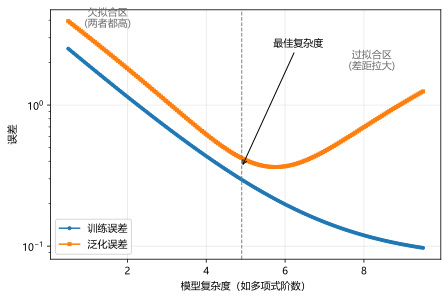

In [23]:
# 模型复杂度 vs 误差 的经典 U 型曲线（示意图）
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False

x = np.linspace(0.5, 9.5, 200)
train_loss = 3.2 * np.exp(-0.55 * x) + 0.08                     # 训练误差：随复杂度单调下降
test_loss = train_loss * 1.15 + 0.05 * (x - 4.9) ** 2 + 0.08    # 泛化误差：先降后升（U 型）

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, train_loss, 'o-', ms=3, label='训练误差')
ax.plot(x, test_loss, 's-', ms=3, label='泛化误差')
ax.axvline(4.9, color='gray', ls='--', lw=1)
ax.annotate('最佳复杂度', xy=(4.9, test_loss.min()), xytext=(5.7, 2.6),
            arrowprops=dict(arrowstyle='->'))
ax.text(1.5, 3.6, '欠拟合区\n(两者都高)', ha='center', color='dimgray', fontsize=10)
ax.text(8.2, 1.8, '过拟合区\n(差距拉大)', ha='center', color='dimgray', fontsize=10)
ax.set_xlabel('模型复杂度（如多项式阶数）')
ax.set_ylabel('误差')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [24]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n) = (n-1)!
# labels 的维度: (n_train + n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [25]:
# NumPy ndarray 转换为 tensor
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32) for x in
    [true_w, features, poly_features, labels]]

# 查看前 2 个样本：第 1 列是与偏置对应的常量特征 x^0/0! = 1
features[:2], poly_features[:2, :], labels[:2]

(tensor([[1.1289],
         [1.0552]]),
 tensor([[1.0000e+00, 1.1289e+00, 6.3720e-01, 2.3978e-01, 6.7671e-02, 1.5279e-02,
          2.8747e-03, 4.6360e-04, 6.5420e-05, 8.2059e-06, 9.2636e-07, 9.5069e-08,
          8.9436e-09, 7.7665e-10, 6.2625e-11, 4.7132e-12, 3.3254e-13, 2.2083e-14,
          1.3849e-15, 8.2287e-17],
         [1.0000e+00, 1.0552e+00, 5.5669e-01, 1.9580e-01, 5.1651e-02, 1.0900e-02,
          1.9169e-03, 2.8895e-04, 3.8111e-05, 4.4682e-06, 4.7147e-07, 4.5226e-08,
          3.9767e-09, 3.2278e-10, 2.4328e-11, 1.7113e-12, 1.1286e-13, 7.0049e-15,
          4.1063e-16, 2.2805e-17]]),
 tensor([5.5434, 5.6389]))

In [26]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和, 样本数量
    for X, y in data_iter:
        out = net(X)
        y = d2l.reshape(y, out.shape)
        l = loss(out, y)
        metric.add(d2l.reduce_sum(l), d2l.size(l))
    return metric[0] / metric[1]

def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式特征中实现了它（x^0/0! = 1）
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 5.0236387  1.1924735 -3.4239588  5.6132417]]


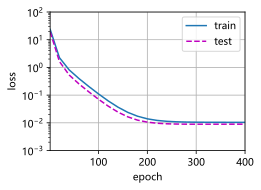

In [27]:
# 从多项式特征中选择前 4 个维度，即 1, x, x^2/2!, x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.3278506 3.4257326]]


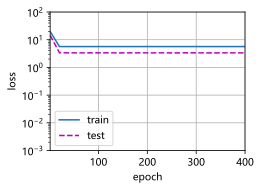

In [28]:
# 从多项式特征中选择前 2 个维度，即 1 和 x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 5.0203118e+00  1.2766248e+00 -3.3563006e+00  5.1615520e+00
  -3.2601824e-01  1.4379517e+00  9.6418194e-02  1.3423891e-01
   1.4293732e-01  3.1401191e-02 -1.6382433e-01  1.3234936e-01
  -1.8457419e-01 -5.1389188e-02  7.3940650e-02 -6.1134245e-02
   3.7244684e-03  2.8378643e-02  9.5004976e-02 -1.6061708e-01]]


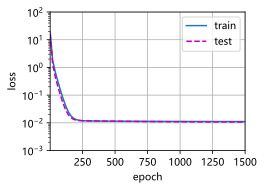

In [29]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

## 4.5 权重衰减

前两节我们已经能"诊断"过拟合，本节开始学习**治疗**手段。**权重衰减（weight decay）**，又称 **L2 正则化（L2 regularization）**，是深度学习中最古老、最常用、最可靠的防过拟合技术——从 20 世纪的岭回归到今天的 Transformer 训练，它无处不在。

### 回顾：已有的"控制复杂度"手段太粗糙

4.4 节说过，影响过拟合的关键因素是**可训练参数量**与**训练样本量**。但据此控制复杂度有两个困难：

1. **粒度太粗**。多项式次数、网络层数这种"一刀切"的旋钮难以做细微调整；我们更希望"所有权重都小一点"，而不是"干脆去掉一部分参数"。
2. **参数多 $\ne$ 一定过拟合**。参数更多的模型也可能泛化更好，单调关系并不成立。

教材用**单项式（monomial）**说明这一点：单项式是由变量幂的乘积构成的项（如 $x_1^2 x_2$，次数 = 各变量幂之和）。$k$ 个变量的 $d$ 阶多项式共含 $\binom{k-1+d}{d}$ 个单项式——$d$ 增大时项数**指数级爆炸**。"数一数参数"这种复杂度度量太粗糙了。

我们需要一种**细粒度、连续可调**的复杂度控制：让每个权重的大小都受到约束。这就是权重衰减。

### 20. L2 正则化：范数与权重衰减

**核心思想**：在原损失函数后加一个惩罚项，惩罚"权重过大"的模型：

$$\min_{\mathbf{w},b}\; \ell(\mathbf{w}, b) + \frac{\lambda}{2}\|\mathbf{w}\|^2, \qquad \|\mathbf{w}\|^2=\sum_{i=1}^{d} w_i^2$$

$\lambda \ge 0$ 是**正则化超参数**：$\lambda=0$ 完全关闭正则化；$\lambda$ 越大惩罚越重、权重被压得越小。用验证集挑选。

**几个设计细节**：

- **为什么用平方范数 $\|\mathbf{w}\|^2$ 而不是欧氏距离 $\|\mathbf{w}\|$**：平方对每个 $w_i$ 的导数是 $2w_i$，干净好算；开平方在 $\mathbf{w}=0$ 处不可导。
- **为什么系数是 $\lambda/2$**：纯粹为了求导时把 2 约掉（$\frac{\partial}{\partial w_i}\frac{\lambda}{2}w_i^2=\lambda w_i$），公式更整洁。
- **为什么通常不惩罚偏置 $b$**：权重决定函数的"陡峭/摆动程度"（复杂度），偏置只负责平移曲线，不增加复杂度；惩罚偏置徒增欠拟合风险。

**统计学渊源**：L2 正则化的线性回归叫**岭回归（ridge regression）**（Tikhonov 正则）；换成 L1 惩罚 $\lambda\sum_i |w_i|$ 则是**套索回归（lasso regression）**——L1 会把一部分权重**精确压到 0**，相当于自动**特征选择**。当特征高度相关时，L2 把权重"摊开"分给相关特征，通常比 L1 的"独宠其一"更稳定。

**为什么叫"权重衰减"（weight decay）？** 对平方损失做 SGD，总梯度为 $\lambda\mathbf{w} + \partial_{\mathbf{w}}\ell$，代入更新规则：

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\left(\lambda\mathbf{w} + \partial_{\mathbf{w}}\ell\right) = \underbrace{(1-\eta\lambda)}_{\text{先衰减}}\mathbf{w} \;-\; \eta\,\partial_{\mathbf{w}}\ell$$

**每一步都先把权重乘一个略小于 1 的因子 $(1-\eta\lambda)$，再走常规梯度步**——权重在每次更新中都被"衰减"一点，名字由此而来。训练全程就是"把权重拉向 0 的力"与"拟合数据的力"的拉锯，最终收敛到范数较小的解。

### 21. 高维线性回归实验

故意构造一个**必然过拟合**的场景来观察权重衰减的威力：**特征维度远大于样本数**（$d=200 \gg n_{train}=20$）。这种设置下线性模型总能完美记住训练集（权重可以自由地大幅震荡去拟合每个样本），过拟合几乎注定。

标签按线性模型生成（含噪声）：

$$y = 0.05 + \sum_{i=1}^{d} 0.01\, x_i + \epsilon,\qquad \epsilon\sim\mathcal{N}(0, 0.01^2)$$

**实验设计一览**

| 设置 | 值 | 用意 |
|---|---|---|
| 输入维度 $d$ | 200 | 特征很多 |
| 训练样本 $n_{train}$ | 20 | 极少 → 必然过拟合 |
| 测试样本 $n_{test}$ | 100 | 衡量泛化 |
| 真实权重 | 全部 $0.01$ | 真实模型"权重很小"：$\lVert\mathbf{w}\rVert_2 = 0.01\sqrt{200}\approx 0.14$ |
| 真实偏置 $b$ | 0.05 | — |
| 噪声标准差 | 0.01 | 较小 |

In [37]:
import torch
from torch import nn
from d2l import torch as d2l

# d=200 远大于 n_train=20 → 模型注定过拟合
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = d2l.ones((num_inputs, 1)) * 0.01, 0.05

train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

### 22. 从零开始实现权重衰减

三步：

1. **初始化**：权重从 $\mathcal{N}(0,1)$ 采样（标准差 1，而真实权重只有 0.01）——初始参数"个头很大"，再配合 20 个样本，给过拟合留足发挥空间；
2. **惩罚项**：`l2_penalty(w) = sum(w**2) / 2`，实现 $\|\mathbf{w}\|^2/2$；
3. **训练**：损失 = 数据损失 $+\ \lambda\cdot$ 惩罚项。注意 `l2_penalty(w)` 是标量，与形状为 `(batch_size, 1)` 的 `loss(net(X), y)` 相加时靠**广播**对齐。

`evaluate_loss` 复用 4.4 节定义的 #@save 函数；这里的 `train` 会**覆盖** 4.4 节的同名函数（教材本身如此，两者参数完全不同，顺序执行互不影响）。

In [38]:
def init_params():
    """初始化模型参数：权重噪声很大（标准差 1，真实值仅 0.01），偏置为 0"""
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

def l2_penalty(w):
    """L2 惩罚项 ||w||²/2（λ 系数在 train 中相乘）"""
    return torch.sum(w.pow(2)) / 2

def train(lambd):
    """λ=0 即普通训练；λ>0 即权重衰减（覆盖 4.4 节同名函数）"""
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加 L2 范数惩罚项；广播使 l2_penalty(w) 与批量内每个样本的损失对齐
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

### 23. 忽略正则化直接训练（λ = 0）

$\lambda=0$ 就是普通训练。结果是 4.4 节"过拟合"的标准剧本：

- **训练误差持续下降**——模型在 20 个样本上越拟合越狠；
- **测试误差先降后升**，训练/测试曲线明显分离；
- $\mathbf{w}$ 的 L2 范数远大于真实权重的范数（约 0.14）——模型用"剧烈震荡的大权重"去记忆噪声。

w的L2范数是： 13.128313064575195


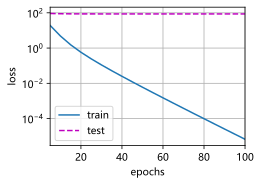

In [32]:
# λ=0：无权重衰减 → 严重过拟合（train/test 分离，w 范数大）
train(lambd=0)

### 24. 使用权重衰减（λ = 3）

$\lambda=3$ 后画面完全反转：

- **训练误差略增**（拟合数据的力被衰减项牵制）；
- **测试误差明显下降**，且与训练误差贴近——泛化 gap 几乎消失；
- $\mathbf{w}$ 的 L2 范数大幅缩小，接近真实权重的水平。

这正是我们期望正则化做的事：**用一点点训练集上的拟合能力，换来测试集上实打实的改善**。

w的L2范数是： 0.35393252968788147


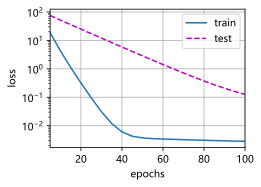

In [39]:
# λ=3：权重衰减生效 → 测试误差下降、贴近训练误差，w 范数显著变小
train(lambd=3)

### 25. 简洁实现

权重衰减太常用，深度学习框架直接把它**集成进优化器**——好处是能与任何损失函数组合，且几乎零额外计算开销（衰减只依赖参数当前值，更新时顺手完成）。

**PyTorch 的做法**：`torch.optim.SGD(..., weight_decay=wd)`。注意两点：

1. **默认衰减所有传入的参数**（包括偏置）。想"只衰减权重"，就用**参数组（param groups）**：传入一个字典列表，每组可带专属超参数——权重组设 `weight_decay=wd`，偏置组不设（默认 0）。
2. **换算口径**：PyTorch 的实现是"梯度直接加上 `wd * w`"（更新式 $w \leftarrow (1-\eta\cdot\text{wd})w - \eta g$），因此 `weight_decay` 就等于本节的 $\lambda$。其他框架/文献中有的定义带 $1/2$ 系数，用前须查文档。

In [40]:
def train_concise(wd):
    """简洁实现：优化器内置权重衰减 + 参数组实现偏置不衰减"""
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params": net[0].weight, 'weight_decay': wd},
        {"params": net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 12.60099983215332


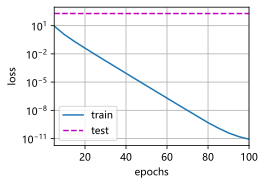

In [41]:
# 不使用权重衰减：过拟合
train_concise(0)

w的L2范数： 0.46620768308639526


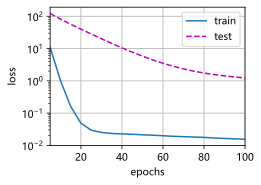

In [42]:
# 使用权重衰减：与从零实现结果一致，但更快、更省事
train_concise(3)

### 26. 原理深入：为什么"压小权重"能抗过拟合？

教材讲清了"怎么做"，这里补三层"为什么"。

**① 约束优化的几何视角：被拉回来的解更平滑**

$\min \ell(\mathbf{w}) + \frac{\lambda}{2}\|\mathbf{w}\|^2$ 等价于带约束问题 $\min \ell(\mathbf{w})\ \text{s.t.}\ \|\mathbf{w}\|^2 \le C$（$\lambda$ 对应拉格朗日乘子）。无约束的最优解往往躲在损失面的"窄谷"深处——那是靠大权重记忆噪声换来的极小训练损失。惩罚项相当于画了一个半径为 $C$ 的球，把解**拉回球的边界**（损失等高线与球面**相切**处）。相切点上数据梯度与"指向原点的回拉力"平衡：$\nabla_{\mathbf{w}}\ell = -\lambda\mathbf{w}$。被约束的权重幅度小 → 函数对输入扰动的敏感度低 → **更平滑 → 泛化更好**。

**② 贝叶斯视角：L2 正则 = 高斯先验**

MAP（最大后验）估计 $\arg\max_w P(w\mid y) \propto P(y\mid w)P(w)$ 取负对数后为 $-\log P(y\mid w) - \log P(w)$：

- 似然取高斯噪声 → 第一项是平方损失；
- **先验取高斯分布 $w\sim\mathcal{N}(0,\sigma_p^2)$** → $-\log P(w) = \frac{\|w\|^2}{2\sigma_p^2} + \text{const}$，正是 **L2 惩罚**，且 $\lambda \propto \sigma_{noise}^2/\sigma_p^2$——**先验越"自信权重接近 0"，$\lambda$ 越大**；
- 先验换成**拉普拉斯分布**（尖峰、重尾）→ $-\log P(w) \propto \sum_i |w_i|$，即 **L1**：对大权重惩罚相对温和、对小权重惩罚相对更狠，最优解倾向落在坐标轴上 → 稀疏。

这也回答了练习 6：**正则化强度 $\lambda$ 本质是"对参数先验信念"的强度**。

**③ 数值视角：岭回归让病态问题变可解**

正规方程解为 $(\mathbf{X}^\top\mathbf{X} + \lambda I)^{-1}\mathbf{X}^\top\mathbf{y}$。当 $d>n$ 或特征共线时 $\mathbf{X}^\top\mathbf{X}$ 奇异/病态；加 $\lambda I$（$\lambda>0$）后**恒正定、恒可逆**，条件数改善——"ridge（岭）"指的就是把特征值从 0 抬起来的那道"山岭"。本节 $d=200 \gg n=20$ 正是病态场景。

**两个实践提醒**

- **$\eta$ 与 $\lambda$ 耦合**：实际衰减强度由乘积 $\eta\lambda$ 决定。调学习率时正则强度也在变，二者别各调各的还指望效果可加。
- **AdamW**：在 Adam 这类自适应优化器里，$\lambda\mathbf{w}$ 混在梯度中会被自适应缩放搅乱（不同参数的有效衰减强度不一致）。AdamW 把衰减**从梯度中解耦**、直接作用在参数上（$w \leftarrow w - \eta\lambda w$，独立于自适应步），如今是大模型训练的标配——本质仍是本节的权重衰减，只是实现更正确。

最后，教材留了个开放性尾巴：对**非线性**模型，"简单"如何定义？**再生核希尔伯特空间（RKHS）**能把线性函数的范数工具推广到非线性情形，但对大型高维数据不实用。实践中深度学习的默认做法就是本书后续采用的启发式：**在深层网络的所有层上应用权重衰减**。

## 4.6 暂退法（Dropout）

上一节的权重衰减通过惩罚权重的 $L_2$ 范数来正则化统计模型。本节介绍深度学习中最常用的另一种正则化技术——**暂退法（dropout，也译"随机失活"、"丢弃法"）**。

**核心思想**：训练时在前向传播过程中，计算每一内部层的同时**随机"丢弃"（置零）一些神经元**；测试时使用完整网络。

从概率角度看，权重衰减相当于假设权重取自均值为 0 的高斯先验；而更直观的想法是：希望模型**深度挖掘特征**（把权重分散到许多特征上），而不是过于依赖少数潜在的虚假关联。本节依次讨论：

- 重新审视过拟合：为什么深度网络格外需要正则化；
- 扰动的稳健性：dropout 的动机与核心公式；
- 从零开始实现与简洁实现，并在 Fashion-MNIST 上验证。

### 27. 重新审视过拟合

线性模型的泛化可靠性是有代价的——它**不考虑特征之间的交互作用**：对每个特征必须单独指定正的或负的权重，而忽略其他特征。这种"泛化性 vs 灵活性"的基本权衡就是**偏差-方差权衡（bias-variance tradeoff）**：

- **线性模型**：偏差很高（只能表示一小类函数），方差很低（在不同的随机数据样本上能得出相似的结果）；
- **深度神经网络**：位于偏差-方差谱的另一端——不局限于单独查看每个特征，而是学习特征之间的交互（例如"尼日利亚"和"西联汇款"一起出现在邮件中→垃圾邮件，单独出现则不是），偏差低、方差高。

**即使样本远多于特征，深度网络也可能过拟合。** 2017 年的**随机标签实验**：把训练图像的标签随机打乱后训练深度网络，模型仍能**完美拟合训练集的每一幅图像**（人类根本记不住输入与随机标签的对应）。若标签是 10 类均匀随机分配，模型在测试数据上的精度不可能高于 10%，于是**泛化差距高达 90%**——如此严重的过拟合，展示了神经网络极大的灵活性。

深度网络的泛化性质的数学基础至今仍是悬而未决的研究问题。本节聚焦**实用工具**：在保留深度网络灵活性的同时，抑制其过拟合。

### 28. 扰动的稳健性

什么是一个"好"的预测模型？——在未知数据上表现好。经典泛化理论认为，缩小训练/测试差距应追求"简单"模型；权重衰减用**参数范数**度量简单性。**简单性的另一个角度是平滑性**：函数不应对其输入的微小变化敏感（例如给图像像素加一些随机噪声，分类结果应基本不变）。

- **Bishop（1995）**证明：训练时向输入添加高斯噪声 $\epsilon \sim \mathcal{N}(0, \sigma^2)$（扰动点 $\mathbf{x}' = \mathbf{x} + \epsilon$，且 $E[\mathbf{x}'] = \mathbf{x}$）**等价于 Tikhonov 正则化**——用数学证实了"要求函数光滑"与"要求函数对输入噪声具有适应性"之间的联系。
- **Srivastava 等人（2014）**把这个想法推广到网络的**内部层**：训练时在计算后续层之前，向网络的每一层注入噪声（只靠输入噪声只会在输入-输出映射上增强平滑性）。这就是**暂退法（dropout）**——名字源于表面上看是在训练中"丢弃（drop out）"一些神经元。

原始论文还给出一个**有性繁殖的类比**：神经网络过拟合与每一层过度依赖前一层的特定激活值有关，称为"**共适应性**"；暂退法会破坏共适应性，就像有性繁殖会破坏共适应的基因一样。

**关键挑战：如何注入噪声？** 应当以**无偏向（unbiased）**的方式注入——固定其他层时，这一层的期望值等于没有噪声时的值。标准暂退法：每个中间活性值 $h$ 以**暂退概率** $p$ 被随机变量 $h'$ 替换：

$$
h' = \begin{cases} 0, & \text{概率为 } p \\ \frac{h}{1-p}, & \text{其他情况} \end{cases}
$$

因此期望保持不变：$E[h'] = p \cdot 0 + (1-p) \cdot \frac{h}{1-p} = h$。即：以概率 $p$ 把一个激活值置零（对应神经元本层"消失"，其梯度在反向传播中也消失），否则保留并放大 $\frac{1}{1-p}$ 倍以补偿期望。

### 29. 实践中的暂退法

将暂退法应用到隐藏层后，每次前向传播得到的结果可以看作一个**只包含原始神经元子集**的网络：例如丢弃了 $h_2, h_5$，则输出的计算不再依赖它们。这样，输出层的计算**不能过度依赖隐藏层中的任何一个元素**。

- **训练时**：每次迭代都独立随机采样一组被丢弃的节点——相当于每一步都在训练一个不同的子网络；
- **测试时**：通常**不使用暂退法**。给定训练好的模型和新样本，不丢弃任何节点，因此也**不需要重新缩放**（训练时的 $\frac{1}{1-p}$ 缩放已保证激活期望一致）；
- **例外**：一些研究人员在测试时也使用暂退法来估计神经网络预测的**不确定性**：如果通过许多不同的暂退遮盖后得到的预测结果都一致，说明网络发挥更稳定。

常见做法：把 dropout 作用在**全连接隐藏层的输出**上（激活函数之后），每层可设不同的暂退概率；**常见的技巧是在靠近输入层的地方设置较低的暂退概率**（如第一个隐藏层 0.2、第二个 0.5）。$p$ 是超参数：$p=0$ 即无 dropout，$p$ 越大正则化越强。

### 30. 从零开始实现

实现单层暂退法函数：从均匀分布 $U[0,1]$ 中抽取与该层维度一致的样本，**保留样本值大于 $p$ 的节点，丢弃其余**；再把保留部分除以 `1.0-dropout`（放大 $\frac{1}{1-p}$ 倍）以消除偏差。

In [43]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

In [44]:
X = torch.arange(16, dtype=torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  4.,  6.,  8., 10., 12.,  0.],
        [ 0., 18.,  0.,  0.,  0.,  0., 28., 30.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


### 31. 定义模型

仍使用 Fashion-MNIST，定义具有**两个隐藏层（各含 256 个单元）的多层感知机**。将暂退法应用于每个隐藏层的**输出（激活函数之后）**：第一个隐藏层丢弃概率 0.2，第二个 0.5；暂退法**只在训练期间有效**（这里通过 `self.training` 标志手动控制，简洁实现中由 `net.train()` / `net.eval()` 自动切换）。

In [45]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

### 32. 训练和测试

训练循环与之前的多层感知机完全一样（`d2l.train_ch3`）——dropout 逻辑封装在模型内部，对训练代码透明。`d2l.train_ch3` 内部在训练每个 epoch 前调用 `net.train()`、评估前调用 `net.eval()`，正确切换 dropout 的开关。

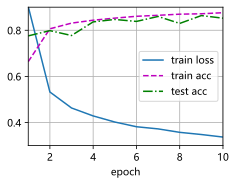

In [46]:
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

### 33. 简洁实现

对于深度学习框架的高级 API，只需在每个全连接层之后添加一个 `Dropout` 层，将暂退概率作为唯一参数传给构造函数。训练时，`Dropout` 层按指定概率随机丢弃上一层的输出（即下一层的输入）；**测试时仅传递数据**——训练/推断模式由 `net.train()` / `net.eval()` 切换。

In [49]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    # 在第一个全连接层之后添加一个dropout层
    nn.Dropout(dropout1),
    nn.Linear(256, 256),
    nn.ReLU(),
    # 在第二个全连接层之后添加一个dropout层
    nn.Dropout(dropout2),
    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

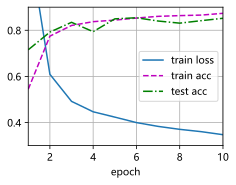

In [50]:
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

### 34. 原理深入：为什么"随机丢弃"能抗过拟合？

把散落在论文与工程实践中的理解汇总如下。

**1. 无偏向噪声 = 平滑性正则。** dropout 在每个激活值上注入期望不变的随机扰动，强迫模型对"中间计算的微小变化不敏感"，与 Bishop 输入高斯噪声 ≈ Tikhonov 正则一脉相承。在线性回归 + 平方损失的简单情形下可以证明：dropout 的期望损失**近似等价于带特定系数的 L2 正则化**（丢弃概率 $p$ 越大、惩罚越强）；在深度网络中，它是一种随数据与网络状态自适应的"活"正则。

**2. 隐式集成（implicit ensembling / 近似 bagging）。** 每次前向传播随机丢弃一批神经元，相当于从指数级多的子网络中随机采样一个来训练；测试时用完整网络预测，近似于**所有子网络预测的平均**。与标准 bagging 的区别：bagging 的各模型独立训练、参数不共享、需显式存储多个模型并投票；dropout 只训练一次，子网络共享权重与数据，最后"免费"得到集成效果。

**3. 打破共适应性（co-adaptation）。** 神经元之间可能形成"你失效我就失效"的脆弱依赖——这种依赖便于精确记忆训练样本，但泛化差。dropout 迫使每个神经元要么独立有用，要么与**多种不同的**神经元组合都能协同有用，知识被冗余、分散地编码，学到的特征更鲁棒（即"有性繁殖破坏共适应基因"的类比）。

**4. 期望不变性为什么重要（inverted dropout）。** 缩放放在训练时（除以 $1-p$）使激活的期望在训练/测试两个阶段一致，测试时直接用完整网络、**零额外开销**。若用原始版本（训练不缩放、测试时缩放激活），推理阶段不仅要多算一次、还要记住每层的 $p$，容易出错——inverted dropout 已是所有主流框架的实现方式。

**5. 工程实践要点。**

- **务必切换模式**：训练前 `net.train()`，测试前 `net.eval()`。忘记关 dropout 是高频 bug，症状是测试精度异常低且每次结果随机抖动；
- **放置位置**：全连接层输出上最常见；**输出层不用**（会破坏 logits）；卷积特征图上逐元素 dropout 效果差（相邻像素高度相关，丢一个旁边还在），改用 Spatial Dropout / DropBlock（按通道/按块丢弃）；
- **现代架构**：Transformer 中大量使用——attention 权重上（attention dropout）、前馈网络内部、残差分支输出之后；
- **取值经验**：$p$ 常取 0.2～0.5，隐藏层越宽可越大；可与权重衰减、数据增强、早停叠加使用（收益通常不完全抵消，但边际递减）；
- **与批归一化混用需谨慎**：两者的统计行为会互相干扰，常见做法是调整顺序或不混用。